## Preprocessing and Descriptive Analysis

This notebook prepares the lyrics dataset for the text mining project.

The preprocessing pipeline includes:
- Text cleaning
- Tokenization
- Stopword removal
- Lemmatization

Additionally, a descriptive analysis of the dataset is performed to understand basic characteristics of the lyrics corpus.

In [1]:
import pandas as pd
import numpy as np
import re

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from pathlib import Path

BASE_DIR  = Path.cwd().parent   # notebooks run from notebooks/ subfolder
RAW       = BASE_DIR / "data" / "raw"
PROCESSED = BASE_DIR / "data" / "processed"
OUTPUTS   = BASE_DIR / "outputs"
MODELS    = BASE_DIR / "models"

In [ ]:
# Set to True to re-run all preprocessing even if output already exists
FORCE_RECOMPUTE = False

In [2]:
import nltk

nltk.download("punkt")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to /Users/yaz/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/yaz/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

### General descriptive analysis

###  Dataset information

In [ ]:
import pandas as pd

df = pd.read_csv(RAW / "spotify_top50_us.csv")

In [4]:
import re

def normalize_name(name):
    # remove anything in parentheses, e.g. (feat. ...), (live)
    name = re.sub(r'\(.*?\)', '', str(name))
    # lowercase and remove non-alphanumeric characters
    return re.sub(r'[^a-z0-9]', '', name.lower())

# create normalized song name
df["norm_name"] = df["name"].apply(normalize_name)

before = len(df)

# keep the version with the highest days_in_top50
df = df.sort_values(by="days_in_top50", ascending=False)
df = df.drop_duplicates(subset=["norm_name"], keep="first").reset_index(drop=True)

after = len(df)

# remove helper column
df = df.drop(columns=["norm_name"])

print(f"Removed {before - after} duplicate songs based on normalized name.")

Removed 125 duplicate songs based on normalized name.


In [5]:
print("Dataset shape after duplicate removal:", df.shape)
df.head()

Dataset shape after duplicate removal: (782, 17)


,spotify_id,name,artists,album_name,album_release_date,danceability,energy,valence,tempo,loudness,speechiness,acousticness,instrumentalness,entry_date,exit_date,days_in_top50,lyrics
0,4KULAymBBJcPRpk1yO4dOG,I Remember Everything (feat. Kacey Musgraves),"Zach Bryan, Kacey Musgraves",Zach Bryan,2023-08-25,0.429,0.453,0.155,77.639,-7.746,0.0459,0.5540,0.000002,2023-10-18,2025-06-11,603,[Verse 1: Zach Bryan]\nRotgut whiskey's gonna ...
1,7KA4W4McWYRpgf0fWsJZWB,See You Again (feat. Kali Uchis),"Tyler, The Creator, Kali Uchis",Flower Boy,2017-07-21,0.558,0.559,0.620,78.558,-9.222,0.0959,0.3710,0.000007,2023-10-18,2025-06-11,603,"[Intro: Tyler, The Creator]\nOkay, okay, okay,..."
2,0ofHAoxe9vBkTCp2UQIavz,Dreams - 2004 Remaster,Fleetwood Mac,Rumours (Super Deluxe),1977-02-04,0.828,0.492,0.789,120.151,-9.744,0.0276,0.0644,0.004280,2023-10-20,2025-06-11,601,NaN
3,17phhZDn6oGtzMe56NuWvj,Lose Control,Teddy Swims,I've Tried Everything But Therapy (Part 1),2023-09-15,0.561,0.604,0.242,159.920,-4.409,0.0337,0.1990,0.000019,2023-12-29,2025-06-11,531,[Verse 1]\nSomething's got a hold of me lately...
4,4iZ4pt7kvcaH6Yo8UoZ4s2,Snooze,SZA,SOS,2022-12-09,0.559,0.551,0.392,143.008,-7.231,0.1320,0.1410,0.000000,2023-10-18,2025-03-03,503,[Intro: Leon Thomas III]\nOoh\nI think I know\...


In [6]:
# Language detection and filtering

from langdetect import detect

def detect_language(text):
    try:
        return detect(str(text))
    except:
        return "unknown"

# detect language from original lyrics
df["language"] = df["lyrics"].apply(detect_language)

# inspect languages before filtering
print(df["language"].value_counts())

# keep only English songs
df = df[df["language"] == "en"].reset_index(drop=True)

print("Remaining songs after English filter:", len(df))

language
en    682
es     56
tl     44
Name: count, dtype: int64
Remaining songs after English filter: 682


In [7]:
df.shape

(682, 18)

In [8]:
df.columns

Index(['spotify_id', 'name', 'artists', 'album_name', 'album_release_date',
       'danceability', 'energy', 'valence', 'tempo', 'loudness', 'speechiness',
       'acousticness', 'instrumentalness', 'entry_date', 'exit_date',
       'days_in_top50', 'lyrics', 'language'],
      dtype='str')

In [9]:
df.info

<bound method DataFrame.info of                  spotify_id                                           name  \
0    4KULAymBBJcPRpk1yO4dOG  I Remember Everything (feat. Kacey Musgraves)   
1    7KA4W4McWYRpgf0fWsJZWB               See You Again (feat. Kali Uchis)   
2    17phhZDn6oGtzMe56NuWvj                                   Lose Control   
3    4iZ4pt7kvcaH6Yo8UoZ4s2                                         Snooze   
4    1Qrg8KqiBpW07V7PNxwwwL                                      Kill Bill   
..                      ...                                            ...   
677  11BKm0j4eYoCPPpCONAVwA                                    Bloody Mary   
678  6TZTu1F0gnp8mtzvYZao41                              The Addams Family   
679  6hu1bJBNMeXIepHr1joKW4                                     Meteor Man   
680  0F60WLPs6Oz2slHomvLt9U                                        We Good   
681  06iup3YJ4EsnkSxyQKFfNk                                      She Stank   

                            art

### Summary statistics

In [10]:
df.describe()

,danceability,energy,valence,tempo,loudness,speechiness,acousticness,instrumentalness,days_in_top50
count,682.000000,682.000000,682.000000,682.000000,682.000000,682.000000,682.000000,682.000000,682.000000
mean,0.625290,0.610249,0.458823,121.519897,-7.148872,0.109889,0.282573,0.013944,63.961877
std,0.146249,0.178484,0.229664,29.171657,2.831495,0.112097,0.276327,0.087564,119.390062
min,0.161000,0.068900,0.036500,46.718000,-22.507000,0.024300,0.000008,0.000000,1.000000
25%,0.520250,0.505250,0.280750,97.980750,-8.527750,0.037600,0.047925,0.000000,2.000000
50%,0.628000,0.623000,0.431000,120.014500,-6.569000,0.056650,0.175500,0.000000,8.000000
75%,0.736750,0.739250,0.632750,140.253000,-5.188250,0.134750,0.491750,0.000069,43.750000
max,0.974000,0.972000,0.981000,215.338000,-1.701000,0.921000,0.994000,0.884000,603.000000


### Distribution of Days in Top 50

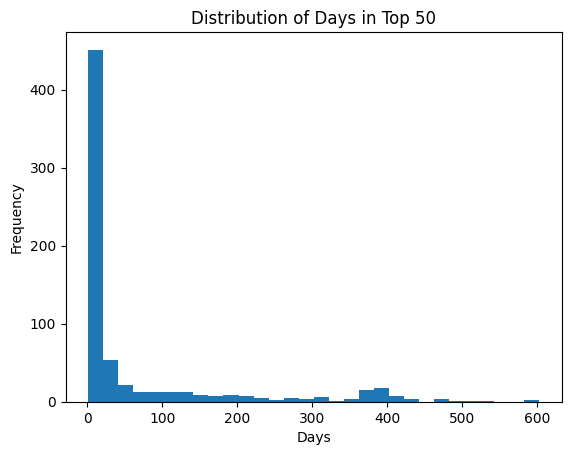

In [11]:
plt.hist(df["days_in_top50"], bins=30)
plt.title("Distribution of Days in Top 50")
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.show()

### Songs with the longest chart runs

In [12]:
df.sort_values("days_in_top50", ascending=False)[["name","artists","days_in_top50"]].head(10)

,name,artists,days_in_top50
0,I Remember Everything (feat. Kacey Musgraves),"Zach Bryan, Kacey Musgraves",603
1,See You Again (feat. Kali Uchis),"Tyler, The Creator, Kali Uchis",603
2,Lose Control,Teddy Swims,531
3,Snooze,SZA,503
4,Kill Bill,SZA,486
6,Sweater Weather,The Neighbourhood,472
5,Stick Season,Noah Kahan,472
7,Money Trees,"Kendrick Lamar, Jay Rock",463
8,Something in the Orange,Zach Bryan,442
9,"Good Luck, Babe!",Chappell Roan,432


### Songs with the shortest chart runs

In [13]:
df.sort_values("days_in_top50", ascending=True)[["name","artists","days_in_top50"]].head(10)

,name,artists,days_in_top50
681,She Stank,Lil Uzi Vert,1
597,Red Button,Drake,1
598,The Shoe Fits,Drake,1
599,Winter Wonderland - Remastered 2006,Bing Crosby,1
600,Given Up On Me,The Weeknd,1
601,TOO MUCH,"The Kid LAROI, Jung Kook, Central Cee",1
602,Total Eclipse of the Heart,Bonnie Tyler,1
603,Big Difference,Nicki Minaj,1
604,Deeper Well,Kacey Musgraves,1
605,Remember Him That Way,Luke Combs,1


### Correlation heatmap

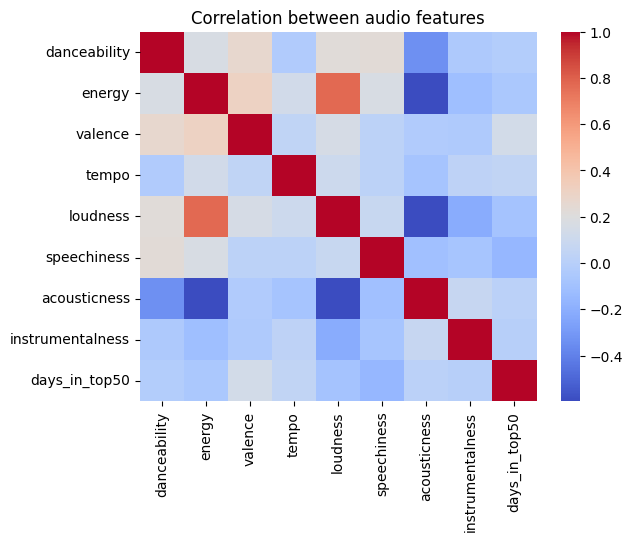

In [14]:
corr = df.select_dtypes(include=["float","int"]).corr()

sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation between audio features")
plt.show()

### Missing Values 

In [15]:
df.isna().sum()

spotify_id            0
name                  0
artists               0
album_name            1
album_release_date    1
danceability          0
energy                0
valence               0
tempo                 0
loudness              0
speechiness           0
acousticness          0
instrumentalness      0
entry_date            0
exit_date             0
days_in_top50         0
lyrics                0
language              0
dtype: int64

In [16]:
print("Missing lyrics:", df["lyrics"].isna().sum())
print("Percentage:", round(df["lyrics"].isna().sum() / len(df) * 100, 2), "%")

Missing lyrics: 0
Percentage: 0.0 %


In [17]:
df[df["lyrics"].isna()].head()

,spotify_id,name,artists,album_name,album_release_date,danceability,energy,valence,tempo,loudness,speechiness,acousticness,instrumentalness,entry_date,exit_date,days_in_top50,lyrics,language


In [18]:
#df = df.dropna(subset=["lyrics"]).copy()

In [19]:
#print("Dataset shape after removing missing lyrics:", df.shape)

Songs with missing lyrics were removed from the dataset since textual analysis requires available lyrics.

### Lyrics length

In [20]:
df["lyrics_length"] = df["lyrics"].apply(len)

In [21]:
df["lyrics_length"].describe()

count     682.000000
mean     2299.675953
std      1160.782929
min       184.000000
25%      1534.750000
50%      2042.500000
75%      2796.000000
max      9825.000000
Name: lyrics_length, dtype: float64

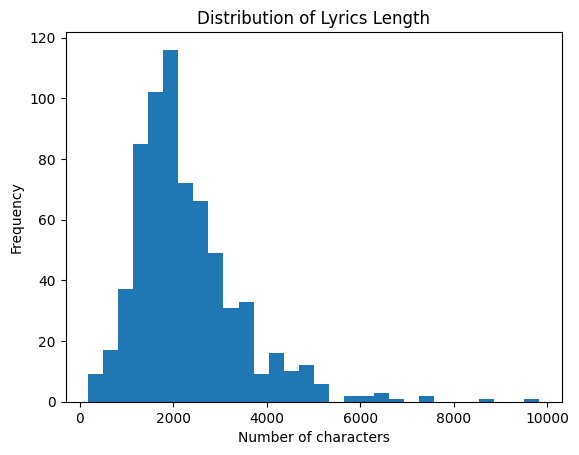

In [22]:
plt.hist(df["lyrics_length"], bins=30)
plt.title("Distribution of Lyrics Length")
plt.xlabel("Number of characters")
plt.ylabel("Frequency")
plt.show()

### Preprocessing

### Basic text cleaning

In [23]:
def clean_lyrics(text):
    text = str(text).lower()
    
    # remove section labels like [Verse], [Chorus], [Intro]
    text = re.sub(r"\[.*?\]", " ", text)
    
    # remove line breaks
    text = text.replace("\\n", " ")
    text = text.replace("\n", " ")
    
    # keep only letters and spaces (removes punctuation, numbers, symbols)
    text = re.sub(r"[^a-z\s]", " ", text)
    
    # remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [24]:
df["lyrics_clean"] = df["lyrics"].apply(clean_lyrics)
df[["lyrics", "lyrics_clean"]].head(20)

,lyrics,lyrics_clean
0,[Verse 1: Zach Bryan]\nRotgut whiskey's gonna ...,rotgut whiskey s gonna ease my mind beach towe...
1,"[Intro: Tyler, The Creator]\nOkay, okay, okay,...",okay okay okay okay okay okay o you live in my...
2,[Verse 1]\nSomething's got a hold of me lately...,something s got a hold of me lately no i don t...
3,[Intro: Leon Thomas III]\nOoh\nI think I know\...,ooh i think i know i ll touch that fire for yo...
4,[Verse 1]\nI'm still a fan even though I was s...,i m still a fan even though i was salty hate t...
5,[Verse 1]\nAs you promised me that I was more ...,as you promised me that i was more than all th...
6,[Verse 1]\nAnd all I am is a man\nI want the w...,and all i am is a man i want the world in my h...
7,"[Verse 1: Kendrick Lamar]\nUh, me and my nigga...",uh me and my niggas tryna get it ya bish ya bi...
8,"[Verse 1]\nIt'll be fine by dusk light, I'm te...",it ll be fine by dusk light i m tellin you bab...
9,"[Verse 1]\nIt's fine, it's cool\nYou can say t...",it s fine it s cool you can say that we are no...


### Stopwords, lemmatizer and preprocessing 

In [25]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# initialize tools
STOP_WORDS = set(stopwords.words("english"))
lmtzr = WordNetLemmatizer()

def preprocess_lemma(text):
    """
    Preprocess text by:
    - tokenizing
    - removing punctuation leftovers
    - removing stopwords
    - lemmatizing
    
    Returns:
        str: processed text as a string of tokens separated by spaces
    """
    tokens = word_tokenize(text)
    
    filtered_tokens = [
        lmtzr.lemmatize(token)
        for token in tokens
        if token not in STOP_WORDS and token.isalpha()
    ]
    
    return " ".join(filtered_tokens)

In [26]:
df["lyrics_preproc"] = df["lyrics_clean"].apply(preprocess_lemma)

df[["lyrics_clean", "lyrics_preproc"]].head(20)

,lyrics_clean,lyrics_preproc
0,rotgut whiskey s gonna ease my mind beach towe...,rotgut whiskey gon na ease mind beach towel re...
1,okay okay okay okay okay okay o you live in my...,okay okay okay okay okay okay live dream state...
2,something s got a hold of me lately no i don t...,something got hold lately know anymore feel li...
3,ooh i think i know i ll touch that fire for yo...,ooh think know touch fire three four time test...
4,i m still a fan even though i was salty hate t...,still fan even though salty hate see broad kno...
5,as you promised me that i was more than all th...,promised mile combined must change heart like ...
6,and all i am is a man i want the world in my h...,man want world hand hate beach stand californi...
7,uh me and my niggas tryna get it ya bish ya bi...,uh nigga tryna get ya bish ya bish ya bish hit...
8,it ll be fine by dusk light i m tellin you bab...,fine dusk light tellin baby thing eat bone dri...
9,it s fine it s cool you can say that we are no...,fine cool say nothing know truth guess fool ar...


### Word count

In [27]:
df["word_count"] = df["lyrics_preproc"].apply(lambda x: len(x.split()))

df["word_count"].describe()

count    682.000000
mean     223.447214
std      120.247082
min       16.000000
25%      140.250000
50%      192.000000
75%      279.000000
max      920.000000
Name: word_count, dtype: float64

### Distribution of Lyrics Length

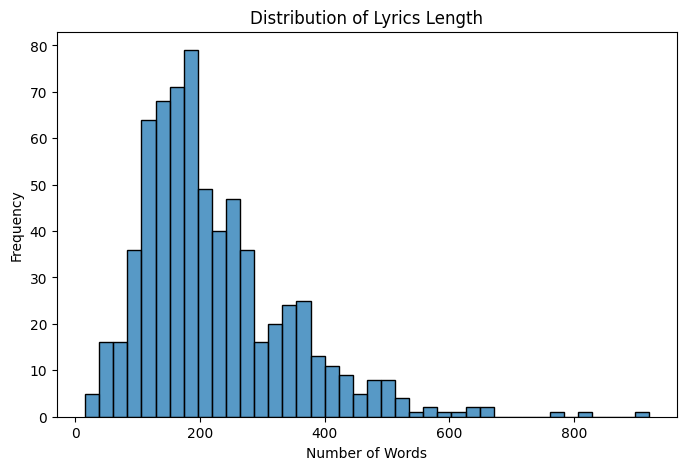

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(df["word_count"], bins=40)

plt.title("Distribution of Lyrics Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

### Longest songs

In [29]:
df.sort_values("word_count", ascending=False)[["name","artists","word_count"]].head()

,name,artists,word_count
259,Family Matters,Drake,920
437,DO IT,"Kanye West, Ty Dolla $ign",817
148,euphoria,Kendrick Lamar,776
7,Money Trees,"Kendrick Lamar, Jay Rock",651
274,meet the grahams,Kendrick Lamar,649


### Shortest songs 

In [30]:
df.sort_values("word_count")[["name","artists","word_count"]].head()

,name,artists,word_count
81,Evergreen,Richy Mitch & The Coal Miners,16
554,OH LOUISIANA,Beyoncé,22
552,Opening Night,The Weeknd,37
23,Blue Christmas,Elvis Presley,37
502,Now And Then,The Beatles,37


In [31]:
total_words = df["word_count"].sum()

print("Total number of words in corpus:", total_words)

Total number of words in corpus: 152391


### Most common words in the corpus

In [32]:
from collections import Counter

all_words = " ".join(df["lyrics_preproc"]).split()

word_freq = Counter(all_words)

word_freq.most_common(40)

[('yeah', 2770),
 ('like', 2640),
 ('know', 1865),
 ('oh', 1797),
 ('got', 1787),
 ('love', 1434),
 ('get', 1417),
 ('na', 1308),
 ('nigga', 1184),
 ('bitch', 1013),
 ('one', 994),
 ('baby', 979),
 ('go', 963),
 ('shit', 939),
 ('uh', 919),
 ('let', 900),
 ('ah', 873),
 ('fuck', 849),
 ('say', 798),
 ('ooh', 793),
 ('cause', 792),
 ('wan', 789),
 ('back', 789),
 ('time', 770),
 ('gon', 723),
 ('make', 705),
 ('never', 667),
 ('want', 665),
 ('see', 638),
 ('tell', 628),
 ('way', 623),
 ('take', 608),
 ('come', 584),
 ('right', 574),
 ('need', 564),
 ('night', 533),
 ('girl', 527),
 ('keep', 524),
 ('huh', 514),
 ('em', 498)]

### Word cloud

In [33]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [34]:
text = " ".join(df["lyrics_preproc"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=100
).generate(text)

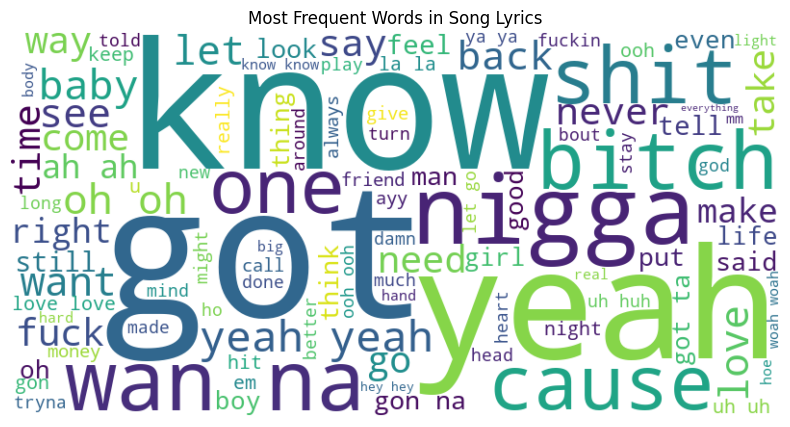

In [35]:
plt.figure(figsize=(10,5))

plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")

plt.title("Most Frequent Words in Song Lyrics")

plt.show()

The most frequent terms include conversational words (e.g., know, got), emotional expressions (e.g., love, baby), and musical fillers such as yeah, oh, and uh, which are typical in song lyrics; therefore, in future preprocessing steps it may be useful to define a set of custom stopwords to remove these filler terms and reduce noise in the analysis.

### Personalized Stopwords

In [36]:
from nltk.corpus import stopwords

# default stopwords
STOP_WORDS = set(stopwords.words("english"))

# custom stopwords common in song lyrics
CUSTOM_STOPWORDS = {
    "yeah", "oh", "uh", "na", "la", "ha ha", "wan", "uh uh",
    "ah", "ooh", "huh", "woah", "mm", "da", "pa", "ya ya",
    "ya", "ayy", "ay", "hmm", "woo", "whoa", "hey",
}

# combine both sets
STOP_WORDS = STOP_WORDS.union(CUSTOM_STOPWORDS)

In [37]:
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

lmtzr = WordNetLemmatizer()

def preprocess_lemma_v2(text):
    
    tokens = word_tokenize(text)
    
    filtered_tokens = [
        lmtzr.lemmatize(token)
        for token in tokens
        if token not in STOP_WORDS and token.isalpha()
    ]
    
    return " ".join(filtered_tokens)

In [38]:
df["lyrics_preproc_v2"] = df["lyrics_clean"].apply(preprocess_lemma_v2)

# create token list column 
df["tokens"] = df["lyrics_preproc_v2"].apply(lambda x: x.split())

df[["lyrics_clean", "lyrics_preproc_v2", "tokens"]].head(20)


,lyrics_clean,lyrics_preproc_v2,tokens
0,rotgut whiskey s gonna ease my mind beach towe...,rotgut whiskey gon ease mind beach towel rest ...,"[rotgut, whiskey, gon, ease, mind, beach, towe..."
1,okay okay okay okay okay okay o you live in my...,okay okay okay okay okay okay live dream state...,"[okay, okay, okay, okay, okay, okay, live, dre..."
2,something s got a hold of me lately no i don t...,something got hold lately know anymore feel li...,"[something, got, hold, lately, know, anymore, ..."
3,ooh i think i know i ll touch that fire for yo...,think know touch fire three four time testify ...,"[think, know, touch, fire, three, four, time, ..."
4,i m still a fan even though i was salty hate t...,still fan even though salty hate see broad kno...,"[still, fan, even, though, salty, hate, see, b..."
5,as you promised me that i was more than all th...,promised mile combined must change heart like ...,"[promised, mile, combined, must, change, heart..."
6,and all i am is a man i want the world in my h...,man want world hand hate beach stand californi...,"[man, want, world, hand, hate, beach, stand, c..."
7,uh me and my niggas tryna get it ya bish ya bi...,nigga tryna get bish bish bish hit house lick ...,"[nigga, tryna, get, bish, bish, bish, hit, hou..."
8,it ll be fine by dusk light i m tellin you bab...,fine dusk light tellin baby thing eat bone dri...,"[fine, dusk, light, tellin, baby, thing, eat, ..."
9,it s fine it s cool you can say that we are no...,fine cool say nothing know truth guess fool ar...,"[fine, cool, say, nothing, know, truth, guess,..."


In [39]:
from collections import Counter

all_words_v2 = " ".join(df["lyrics_preproc_v2"]).split()

word_freq_v2 = Counter(all_words_v2)

word_freq_v2.most_common(20)

[('like', 2640),
 ('know', 1865),
 ('got', 1787),
 ('love', 1434),
 ('get', 1417),
 ('nigga', 1184),
 ('bitch', 1013),
 ('one', 994),
 ('baby', 979),
 ('go', 963),
 ('shit', 939),
 ('let', 900),
 ('fuck', 849),
 ('say', 798),
 ('cause', 792),
 ('back', 789),
 ('time', 770),
 ('gon', 723),
 ('make', 705),
 ('never', 667)]

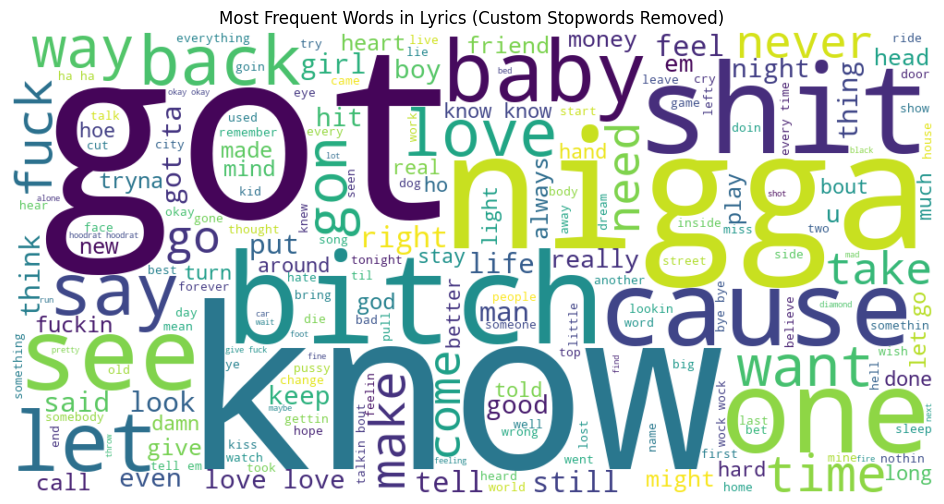

In [40]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# unir todas las letras con stopwords personalizadas removidas
text_v2 = " ".join(df["lyrics_preproc_v2"])

# crear word cloud
wordcloud_v2 = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text_v2)

# mostrar gráfico
plt.figure(figsize=(12,6))
plt.imshow(wordcloud_v2, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Words in Lyrics (Custom Stopwords Removed)")
plt.show()

In [41]:
df.columns

df = df.drop(columns=["lyrics_preproc"])
df.head()

,spotify_id,name,artists,album_name,album_release_date,danceability,energy,valence,tempo,loudness,...,entry_date,exit_date,days_in_top50,lyrics,language,lyrics_length,lyrics_clean,word_count,lyrics_preproc_v2,tokens
0,4KULAymBBJcPRpk1yO4dOG,I Remember Everything (feat. Kacey Musgraves),"Zach Bryan, Kacey Musgraves",Zach Bryan,2023-08-25,0.429,0.453,0.155,77.639,-7.746,...,2023-10-18,2025-06-11,603,[Verse 1: Zach Bryan]\nRotgut whiskey's gonna ...,en,1886,rotgut whiskey s gonna ease my mind beach towe...,172,rotgut whiskey gon ease mind beach towel rest ...,"[rotgut, whiskey, gon, ease, mind, beach, towe..."
1,7KA4W4McWYRpgf0fWsJZWB,See You Again (feat. Kali Uchis),"Tyler, The Creator, Kali Uchis",Flower Boy,2017-07-21,0.558,0.559,0.620,78.558,-9.222,...,2023-10-18,2025-06-11,603,"[Intro: Tyler, The Creator]\nOkay, okay, okay,...",en,2665,okay okay okay okay okay okay o you live in my...,268,okay okay okay okay okay okay live dream state...,"[okay, okay, okay, okay, okay, okay, live, dre..."
2,17phhZDn6oGtzMe56NuWvj,Lose Control,Teddy Swims,I've Tried Everything But Therapy (Part 1),2023-09-15,0.561,0.604,0.242,159.920,-4.409,...,2023-12-29,2025-06-11,531,[Verse 1]\nSomething's got a hold of me lately...,en,1484,something s got a hold of me lately no i don t...,123,something got hold lately know anymore feel li...,"[something, got, hold, lately, know, anymore, ..."
3,4iZ4pt7kvcaH6Yo8UoZ4s2,Snooze,SZA,SOS,2022-12-09,0.559,0.551,0.392,143.008,-7.231,...,2023-10-18,2025-03-03,503,[Intro: Leon Thomas III]\nOoh\nI think I know\...,en,2263,ooh i think i know i ll touch that fire for yo...,177,think know touch fire three four time testify ...,"[think, know, touch, fire, three, four, time, ..."
4,1Qrg8KqiBpW07V7PNxwwwL,Kill Bill,SZA,SOS,2022-12-08,0.644,0.735,0.418,88.980,-5.747,...,2023-10-18,2025-02-14,486,[Verse 1]\nI'm still a fan even though I was s...,en,1762,i m still a fan even though i was salty hate t...,150,still fan even though salty hate see broad kno...,"[still, fan, even, though, salty, hate, see, b..."


In [ ]:
_output_path = PROCESSED / "lyrics_preprocessed.pkl"

if not FORCE_RECOMPUTE and _output_path.exists():
    df = pd.read_pickle(_output_path)
    print("Loaded from cache:", _output_path)
else:
    df.to_pickle(PROCESSED / "lyrics_preprocessed.pkl")
    df.to_csv(PROCESSED / "lyrics_preprocessed.csv", index=False)
    print("Saved to:", PROCESSED)